<a href="https://colab.research.google.com/github/MakarenaAmpuero/retail-sales-analysis/blob/development/Proyecto_Parte_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis de Ventas en una Tienda Retail Nombre: Makarena Ampuero Curso: Data Science Fecha: 07 de Mayo 2026

# Introducción

En esta parte del proyecto se realiza un análisis exploratorio de datos (EDA) del dataset de ventas de una tienda retail. El objetivo es entender mejor los datos, ver cómo se comportan las variables y detectar patrones o valores atípicos.

Para esto se utilizan herramientas como Python, Pandas, NumPy y Matplotlib, junto con gráficos como histogramas, boxplots, gráficos de dispersión y de líneas. Con esto se puede tener una visión general de las ventas y su comportamiento en el tiempo.

# 1. Importar librerias

In [2]:
import pandas as pd
import numpy as np

print("Pandas y Numpy cargados correctamente")

Pandas y Numpy cargados correctamente


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
print("Seaborn y Matplotlib cargados correctamente")

Seaborn y Matplotlib cargados correctamente


# 2. Carga de dataset

In [4]:
df = pd.read_csv('/content/retail_sales_dataset.csv')
print("Dataset cargado correctamente")

Dataset cargado correctamente


In [5]:
print("Dimensión del archivo:", df.shape)

Dimensión del archivo: (1000, 9)


In [6]:
print("Primeras 10 filas del dataset:")
display(df.head(10))

Primeras 10 filas del dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [18]:
print("Información general del dataset:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1000 non-null   int64  
 1   Date              1000 non-null   object 
 2   Customer ID       1000 non-null   object 
 3   Gender            1000 non-null   object 
 4   Age               1000 non-null   int64  
 5   Product Category  1000 non-null   object 
 6   Quantity          1000 non-null   int64  
 7   Price per Unit    1000 non-null   int64  
 8   Total Amount      1000 non-null   int64  
 9   Sales             1000 non-null   int64  
 10  Discount          1000 non-null   float64
 11  Net Sales         1000 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 93.9+ KB
Información general del dataset: None


In [19]:
print("Estadísticas descritivas:", df.describe())

Estadísticas descritivas:        Transaction ID         Age     Quantity  Price per Unit  Total Amount  \
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000   
mean       500.500000    41.39200     2.514000      179.890000    456.000000   
std        288.819436    13.68143     1.132734      189.681356    559.997632   
min          1.000000    18.00000     1.000000       25.000000     25.000000   
25%        250.750000    29.00000     1.000000       30.000000     60.000000   
50%        500.500000    42.00000     3.000000       50.000000    135.000000   
75%        750.250000    53.00000     4.000000      300.000000    900.000000   
max       1000.000000    64.00000     4.000000      500.000000   2000.000000   

             Sales     Discount    Net Sales  
count  1000.000000  1000.000000  1000.000000  
mean    456.000000     0.049600   434.735500  
std     559.997632     0.040205   536.424168  
min      25.000000     0.000000    22.500000  
25%      60.000000

In [9]:
print("Últimas 5 filas del dataset:")
display(df.tail(5))

Últimas 5 filas del dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


#3. Limpieza del dataset

In [20]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Sales               0
Discount            0
Net Sales           0
dtype: int64


In [22]:
# Verificación de registros duplicados
print("Cantidad de filas duplicadas:")
print(df.duplicated().sum())

Cantidad de filas duplicadas:
0


Como parte del proceso de preparación de datos, se realizó una revisión de calidad para identificar valores nulos y registros duplicados. Los resultados muestran que ninguna de las variables presenta datos faltantes y no se detectaron filas duplicadas, por lo que el conjunto de datos se consideró completo, consistente y apto para el análisis exploratorio.

# 4. Transformación de datos
Se crean nuevas columnas para facilitar el análisis y obtener información adicional a partir de los datos existentes.

In [10]:
# Crear variable de ventas
df['Sales'] = df['Quantity'] * df['Price per Unit']

# Crear variable de descuentos simulados
df['Discount'] = np.random.choice(
    [0, 0.05, 0.10],
    size=len(df)
)

# Calcular venta neta después del descuento
df['Net Sales'] = df['Sales'] * (1 - df['Discount'])

print("Nuevas variables creadas correctamente")


Nuevas variables creadas correctamente


# 5. Matriz de correlación

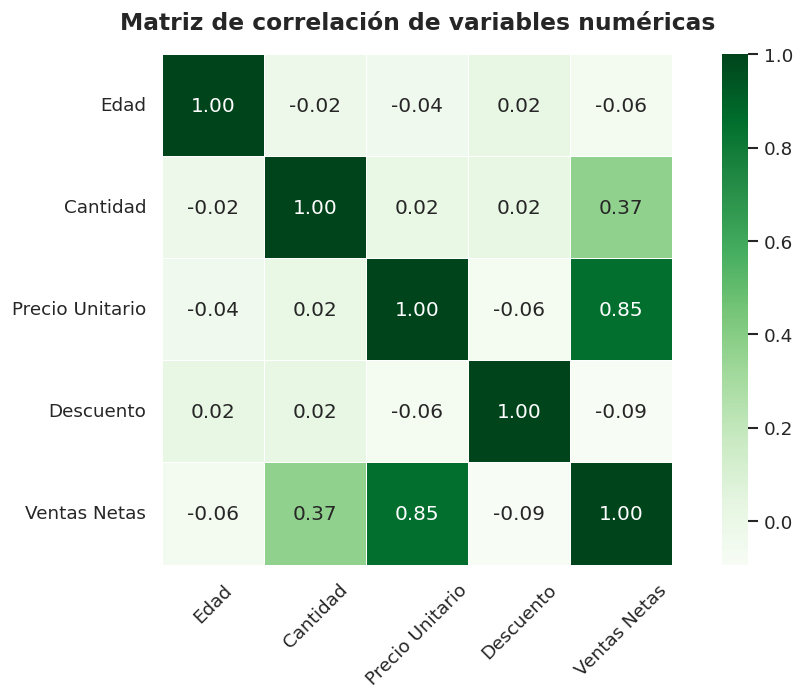

In [17]:
# Seleccionar solamente las variables numéricas que aportan valor
df_corr = df[[
    "Age",
    "Quantity",
    "Price per Unit",
    "Discount",
    "Net Sales"
]].copy()

# Cambio el idioma de las variables
df_corr = df_corr.rename(columns={
    "Age": "Edad",
    "Quantity": "Cantidad",
    "Price per Unit": "Precio Unitario",
    "Discount": "Descuento",
    "Net Sales": "Ventas Netas"
})

# Calculo de la matriz de correlación
corr = df_corr.corr()

# Configuración visual
sns.set_theme(style="whitegrid", font="DejaVu Sans")


#generación del gráfico, elegí verde para ventas (los colores son de Adobe photoshop)
fig, ax = plt.subplots(figsize=(9,6), dpi=120)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    square=True,
    ax=ax
)


ax.set_title(
    "Matriz de correlación de variables numéricas",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

El mapa de correlación muestra que el precio unitario tiene una relación alta con las ventas netas, mientras que la cantidad vendida presenta una relación moderada.
En contraste, edad y descuento muestran una influencia débil.

#6. Histogramas

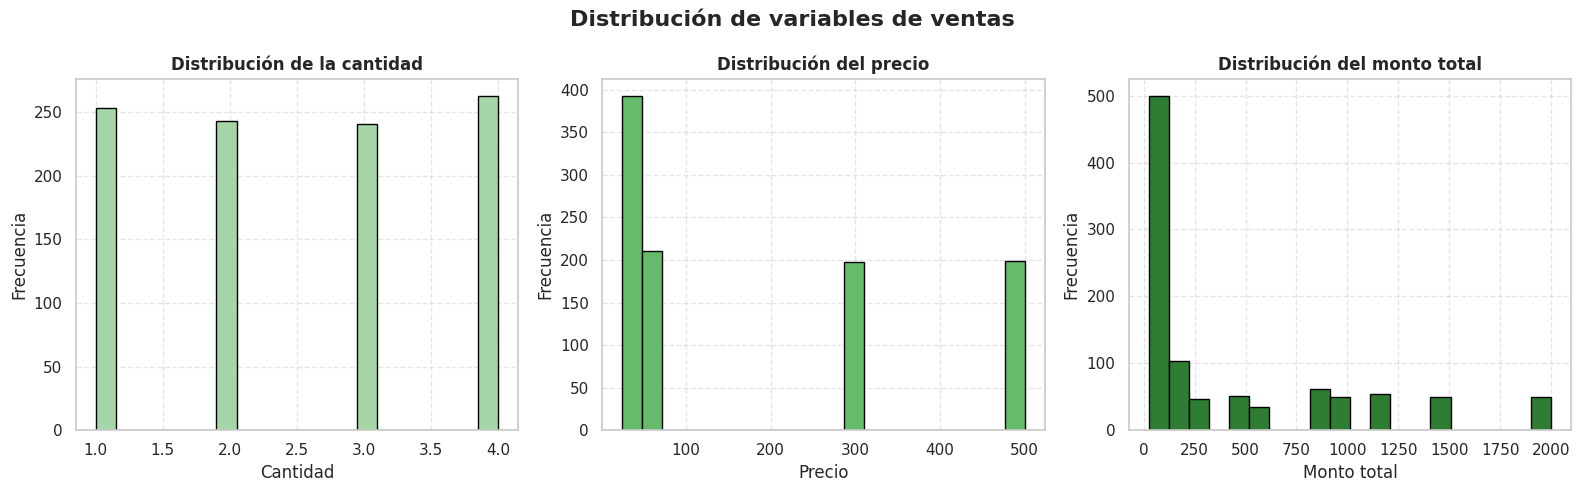

In [ ]:
# Utilizaré histogramas para análizar las variables: cantidad, precio y monto total
fig, ax = plt.subplots(1, 3, figsize=(16,5))

# Generación del gráfico, elegí tonos de verdes para mantener una estética (los colores son de Adobe photoshop)
colors = ["#A5D6A7", "#66BB6A", "#2E7D32"]

# Histograma de cantidad, en intervalos de 20
ax[0].hist(df['Quantity'], bins=20, color=colors[0], edgecolor='black')
ax[0].set_title("Distribución de la cantidad", fontweight='bold')
ax[0].set_xlabel("Cantidad")
ax[0].set_ylabel("Frecuencia")
ax[0].grid(True, linestyle='--', alpha=0.5)

# Histograma de precio unitario
ax[1].hist(df['Price per Unit'], bins=20, color=colors[1], edgecolor='black')
ax[1].set_title("Distribución del precio", fontweight='bold')
ax[1].set_xlabel("Precio")
ax[1].set_ylabel("Frecuencia")
ax[1].grid(True, linestyle='--', alpha=0.5)

# histograma de venta total
ax[2].hist(df['Total Amount'], bins=20, color=colors[2], edgecolor='black')
ax[2].set_title("Distribución del monto total", fontweight='bold')
ax[2].set_xlabel("Monto total")
ax[2].set_ylabel("Frecuencia")
ax[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Distribución de variables de ventas", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

Estos histogramas nos dejan observar la distribución de las variables cantidad, precio y monto total.
En la cantidad, los valores se ven concentrados en pocos niveles (variable discreta)
El precio por unidad es más disperso.
En cuanto al monto total, observamos una distribución más amplia, es decir, ventas más variables, con valores atípicos.

#7. Gráfico de dispersión

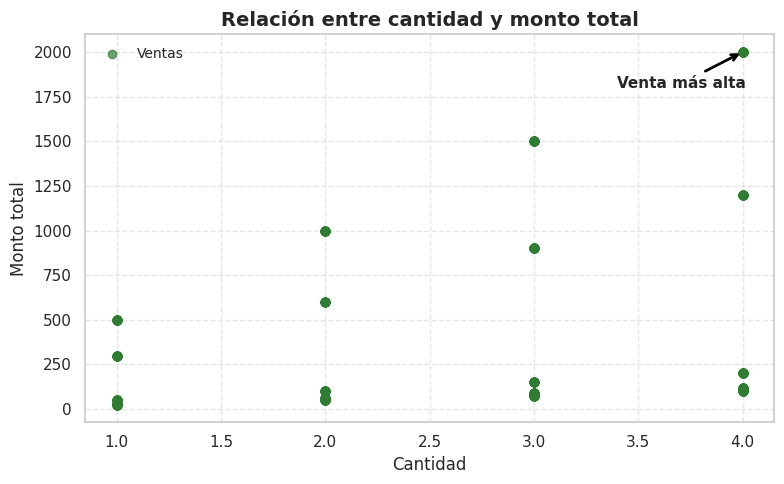

In [ ]:
# gráfico de dispersión para relacionar las variables anteriores, mostrando el valor más alto
fig, ax = plt.subplots(figsize=(8,5))

# generación del gráfico, elegí verde para ventas (los colores son de Adobe photoshop)
ax.scatter(
    df["Quantity"],
    df["Total Amount"],
    color="#2E7D32",
    alpha=0.7,
    label="Ventas"
)

# esta sería la fila con mayor venta y se guardan
max_row = df.loc[df["Total Amount"].idxmax()]

x_point = max_row["Quantity"]
y_point = max_row["Total Amount"]

ax.annotate(
    "Venta más alta",
    xy=(x_point, y_point),
    xytext=(x_point - 0.6, y_point - 200), #ajuste del texto al punto más alto de ventas
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        arrowstyle="->",
        lw=2
    ),
    fontsize=11,
    fontweight="bold"
)

ax.set_title("Relación entre cantidad y monto total", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad")
ax.set_ylabel("Monto total")

ax.legend(loc="upper left", frameon=False, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

El gráfico de dispersión entre cantidad y monto total muestra una tedencia positiva, lo que tiene sentido a mayor cantidad vendida sube el monto total de las ventas. Si tiene una leve dispersión, entonces no solo es la cantidad la que influye en las ventas, el precio por unidad también tiene impacto en las ventas totales.

# 8. Conclusión
Las ventas netas muestran una mayor relación con el precio unitario y una influencia moderada de la cantidad vendida. Los gráficos permitieron identificar patrones, variabilidad y posibles valores atípicos en el comportamiento de las ventas.